In [7]:
import statsmodels.api as sm
import pandas as pd

import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split # Sklearn package's randomized data splitting function


In [2]:
!gdown 1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR

Downloading...
From: https://drive.google.com/uc?id=1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR
To: /content/cars24-car-price-cleaned.csv
100% 1.69M/1.69M [00:00<00:00, 85.0MB/s]


In [5]:
df = pd.read_csv('cars24-car-price-cleaned.csv')

df['make'] = df.groupby('make')['selling_price'].transform('mean')
df['model'] = df.groupby('model')['selling_price'].transform('mean')
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,4.684721,1.180000,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,5.458819,4.818750,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,5.458819,3.394000,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,4.684721,2.242676,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,5.858258,6.777576,0,0,1,0,0,0,1,1,0


In [8]:
df_train, df_test = train_test_split(df, test_size=0.3, random_state=1)

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_train = pd.DataFrame(scaler.fit_transform(df_train), columns=df.columns)

df_test = pd.DataFrame(scaler.transform(df_test), columns=df.columns)

In [11]:
y_train = df_train['selling_price']
X_train = df_train.drop('selling_price', axis=1)


In [12]:
y_train = np.array(y_train)

In [13]:
X_sm = sm.add_constant(X_train)

In [14]:
model = sm.OLS(y_train, X_sm)
results = model.fit()

In [15]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                 1.512e+04
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        15:48:27   Log-Likelihood:                 20674.
No. Observations:               13874   AIC:                        -4.131e+04
Df Residuals:                   13857   BIC:                        -4.119e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -4.64e+11   1.17e+11  

## Assumptions of LR

In [16]:
# Statmodels implementation of Linear regression
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [17]:
X = df[df.columns.drop('selling_price')]
y = df["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)

X_sm = sm.add_constant(X_tr_scaled)  #Statmodels default is without intercept, to add intercept we need to add constant

sm_model = sm.OLS(y_train, X_sm).fit()

print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                 1.701e+04
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        16:20:15   Log-Likelihood:                -24523.
No. Observations:               15856   AIC:                         4.908e+04
Df Residuals:                   15839   BIC:                         4.921e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.5834      0.009    729.235      0.0

In [18]:
X_train.columns

Index(['year', 'km_driven', 'mileage', 'engine', 'max_power', 'age', 'make',
       'model', 'Individual', 'Trustmark Dealer', 'Diesel', 'Electric', 'LPG',
       'Petrol', 'Manual', '5', '>5'],
      dtype='object')

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
vif = pd.DataFrame()

In [21]:
vif

""


In [22]:
X_t = pd.DataFrame(X_tr_scaled, columns=X_train.columns)

In [24]:
vif['Features'] = X_t.columns
vif

,Features
0,year
1,km_driven
2,mileage
3,engine
4,max_power
5,age
6,make
7,model
8,Individual
9,Trustmark Dealer


In [25]:
X_t.shape[1]

17

In [27]:
X_t

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-0.486954,0.158764,-0.896858,0.040307,0.404950,0.486954,-0.168188,-0.473490,-0.803747,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,-2.023235,0.448465,-0.428013
1,0.763433,-0.429161,0.231029,-0.922002,-0.692532,-0.763433,-0.524700,-0.592231,1.244173,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,0.494258,0.448465,-0.428013
2,0.450836,1.316242,0.476821,-0.439884,-0.209961,-0.450836,-0.608249,-0.455186,1.244173,-0.100003,1.013972,-0.021016,-0.058458,-0.975083,-2.023235,0.448465,-0.428013
3,1.076029,-0.277293,-0.308795,-0.540164,-0.252291,-1.076029,-0.201672,-0.315315,-0.803747,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,0.494258,0.448465,-0.428013
4,-1.112147,-0.190317,-0.759031,0.032593,0.264590,1.112147,-0.311621,-0.711439,1.244173,-0.100003,1.013972,-0.021016,-0.058458,-0.975083,0.494258,0.448465,-0.428013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15851,1.388626,-0.534804,-1.337905,1.768220,1.106750,-1.388626,1.085036,2.454137,-0.803747,-0.100003,1.013972,-0.021016,-0.058458,-0.975083,0.494258,-2.229827,2.336377
15852,1.076029,-0.730473,0.573300,-0.538236,-0.363688,-1.076029,-0.524700,-0.497558,1.244173,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,0.494258,0.448465,-0.428013
15853,0.450836,-0.290815,-0.968069,0.221583,0.516347,-0.450836,-0.311621,0.432089,-0.803747,-0.100003,-0.986220,-0.021016,-0.058458,1.025553,0.494258,0.448465,-0.428013
15854,-0.486954,-0.796615,-0.143402,1.000687,1.913264,0.486954,2.961284,2.522708,-0.803747,-0.100003,1.013972,-0.021016,-0.058458,-0.975083,-2.023235,0.448465,-0.428013


In [28]:
vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(17)]

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [29]:
vif

,Features,VIF
0,year,inf
1,km_driven,1.210291
2,mileage,3.235230
3,engine,6.301901
4,max_power,5.023312
5,age,inf
6,make,3.325648
7,model,6.161267
8,Individual,1.088570
9,Trustmark Dealer,1.021996


In [30]:
vif['VIF'] = round(vif['VIF'], 2)

In [31]:
vif

,Features,VIF
0,year,inf
1,km_driven,1.21
2,mileage,3.24
3,engine,6.30
4,max_power,5.02
5,age,inf
6,make,3.33
7,model,6.16
8,Individual,1.09
9,Trustmark Dealer,1.02


In [32]:
vif = vif.sort_values(by = "VIF", ascending = False)

In [33]:
vif

,Features,VIF
0,year,inf
5,age,inf
13,Petrol,18.29
10,Diesel,17.29
16,>5,13.04
15,5,11.75
3,engine,6.30
7,model,6.16
4,max_power,5.02
6,make,3.33


In [35]:
cols2 = vif["Features"][1:].values
cols2

array(['age', 'Petrol', 'Diesel', '>5', '5', 'engine', 'model',
       'max_power', 'make', 'mileage', 'Manual', 'LPG', 'Electric',
       'km_driven', 'Individual', 'Trustmark Dealer'], dtype=object)

## Fitting the model again by removing one feature

In [36]:
X2 = pd.DataFrame(X_tr_scaled, columns=X_train.columns)[cols2]

X2_sm = sm.add_constant(X2)  #Statmodels default is without intercept, to add intercept we need to add constant
sm_model = sm.OLS(list(y_train), X2_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                 1.701e+04
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        16:27:57   Log-Likelihood:                -24523.
No. Observations:               15856   AIC:                         4.908e+04
Df Residuals:                   15839   BIC:                         4.921e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.5834      0.009  

## How can we automate

In [37]:
r2_thr = 0.85
vif_thr = 7

i = 1
feats_removed = ['year']


while True:
  vif = pd.DataFrame()
  X_t = pd.DataFrame(X_tr_scaled, columns=X_train.columns)[cols2]
  vif['Features'] = cols2
  vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
  vif['VIF'] = round(vif['VIF'], 2)
  vif = vif.sort_values(by = "VIF", ascending = False)

  cols2 = vif["Features"][1:].values #taking one less column
  X2 = pd.DataFrame(X_tr_scaled, columns=X_train.columns)[cols2]

  X2_sm = sm.add_constant(X2)  #Statmodels default is without intercept, to add intercept we need to add constant
  sm_model = sm.OLS(list(y_train), X2_sm).fit() #fitting the new model

  if (vif.iloc[0]['VIF'] > vif_thr) or (sm_model.rsquared_adj < r2_thr):
    print('Reached threshold')
    print('Highest vif:',vif.iloc[0])
    print('Current adj.R2',sm_model.rsquared_adj)
    print('Features removed:', i)
    print('List of features removed:', feats_removed)
    break
  feats_removed.append(vif.iloc[0]['Features'])
  i += 1

Reached threshold
Highest vif: Features    model
VIF          6.14
Name: 2, dtype: object
Current adj.R2 0.8322522946246915
Features removed: 3
List of features removed: ['year', 'Petrol', '>5']


In [38]:
print(vif)
print(sm_model.summary())

            Features   VIF
2              model  6.14
1             engine  6.12
3          max_power  4.85
4               make  3.29
5            mileage  2.86
6             Diesel  2.14
7                age  1.87
8             Manual  1.78
0                  5  1.70
9           Electric  1.22
10         km_driven  1.21
11        Individual  1.09
12  Trustmark Dealer  1.02
13               LPG  1.01
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     6052.
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        16:31:36   Log-Likelihood:                -33356.
No. Observations:               15856   AIC:                         6.674e+04
Df Residuals:                   15842   BI

In [ ]:
## Ass - 1 : Linearity

## Assump - 2 No Mulicollinaerity

In [39]:
X_sm = sm.add_constant(X_tr_scaled)
sm_model = sm.OLS(y_train, X_sm).fit()

In [40]:
y_train.shape

(15856,)

In [41]:
Y_hat = sm_model.predict(X_sm)

In [43]:
y_train

,selling_price
3443,4.75
16090,4.00
11070,4.35
19214,6.20
17843,3.25
...,...
1099,19.50
18898,5.20
11798,8.25
6637,19.00


In [44]:
errors = Y_hat - y_train

In [45]:
errors

,selling_price
3443,-0.193651
16090,0.124025
11070,0.404339
19214,-0.389842
17843,-0.006050
...,...
1099,-1.362943
18898,-0.487388
11798,0.450178
6637,-1.146986


Text(0.5, 1.0, 'Histogram of residuals')

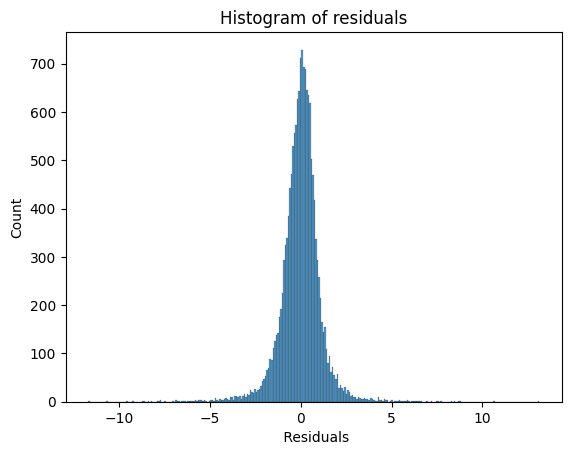

In [46]:
import seaborn as sns
sns.histplot(errors)
plt.xlabel(" Residuals")
plt.title("Histogram of residuals")

In [47]:
from scipy import stats

In [48]:
res = stats.shapiro(errors)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15856.
  res = hypotest_fun_out(*samples, **kwds)


In [49]:
res.statistic

np.float64(0.8901716755445348)

### 4. Error terms must be independent

- If we plot a scatter plot between the target variable and the error term, then
- there shouldn't exist a pattern in the error

Usually occurs in time series data.

- We'll talk about it in detail once we learn time series

<center><img src="https://drive.google.com/uc?id=1YvXocfNA98zLjvnNf4zHF_5BXecBrbVE" width="800" height="400"> </center>

## Break - 10:22 pm

In [50]:
Y_hat = sm_model.predict(X_sm)
errors = Y_hat - y_train

Text(0.5, 1.0, 'Predicted values vs Residuals')

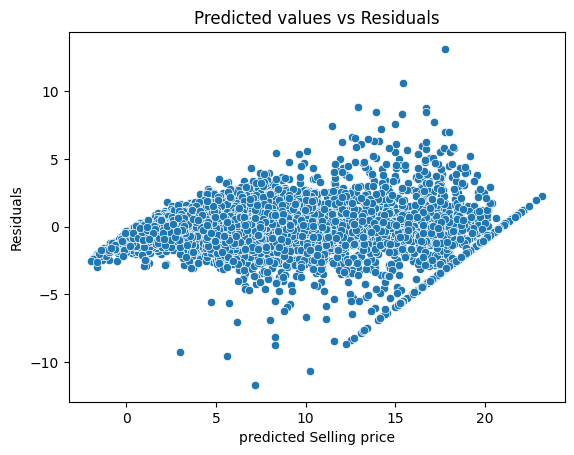

In [51]:
sns.scatterplot(x=Y_hat,y=errors)


plt.xlabel("predicted Selling price")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals")

In [52]:
!gdown 12wjTgfPAXwB7VNMvxm0LRBG8pjxG_ZqQ

Downloading...
From: https://drive.google.com/uc?id=12wjTgfPAXwB7VNMvxm0LRBG8pjxG_ZqQ
To: /content/total-electricity-consumption-us.csv
100% 680/680 [00:00<00:00, 341kB/s]


In [53]:
#fetching data
elec_cons = pd.read_csv("total-electricity-consumption-us.csv",  sep = ',', header= 0 )
elec_cons.head()

,Year,Consumption
0,1920,57125
1,1921,53656
2,1922,61816
3,1923,72113
4,1924,76651


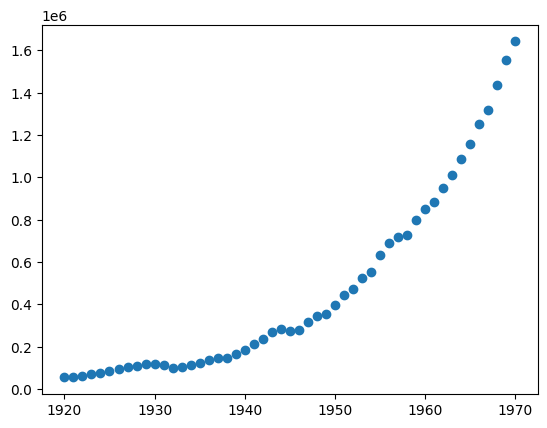

In [54]:
plt.scatter(x=elec_cons['Year'], y= elec_cons['Consumption'])

In [55]:
size = len(elec_cons.index)
index = range(0, size, 5)

train = elec_cons[~elec_cons.index.isin(index)]
test = elec_cons[elec_cons.index.isin(index)]

In [56]:
print(len(train))
print(len(test))

40
11


In [57]:
# converting X to a two dimensional array, as required by the learning algorithm
X_train = train.Year.values.reshape(-1,1) #Making X two dimensional
y_train = train.Consumption

X_test = test.Year.values.reshape(-1,1) #Making X two dimensional
y_test = test.Consumption

In [58]:
r2_train = []
r2_test = []
degrees = [1, 2, 3]

In [59]:
degree =2

In [60]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn import metrics

In [66]:
poly = PolynomialFeatures(degree=3)

In [64]:
X_train.shape

(40, 1)

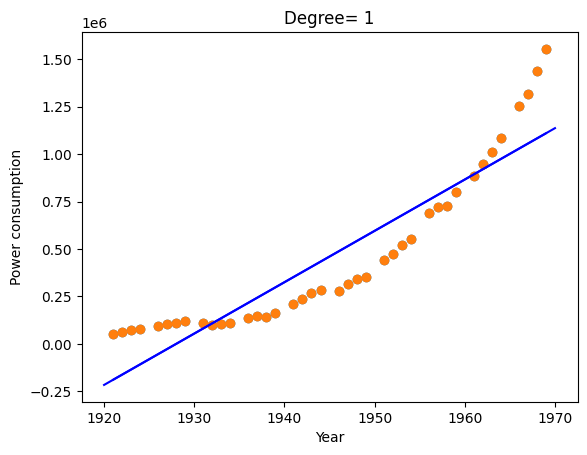

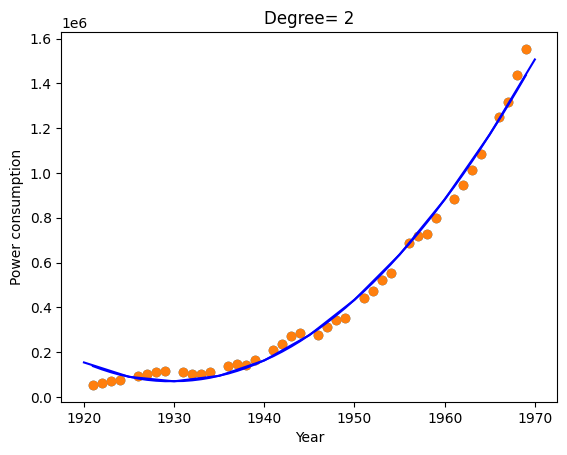

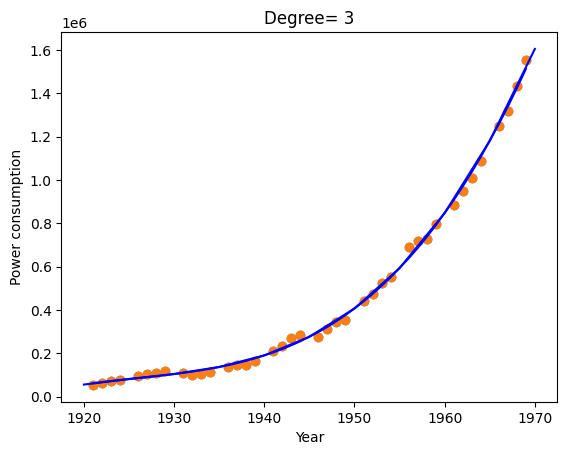

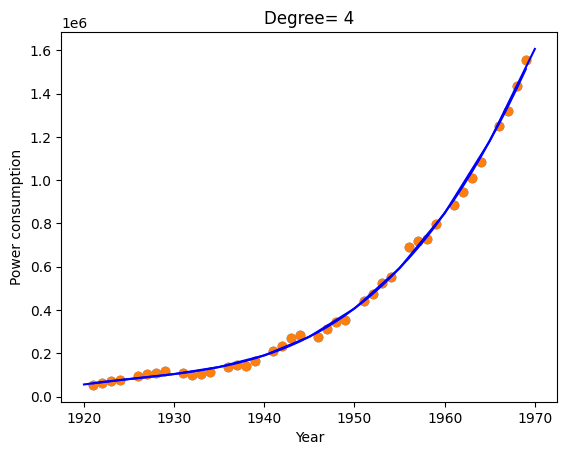

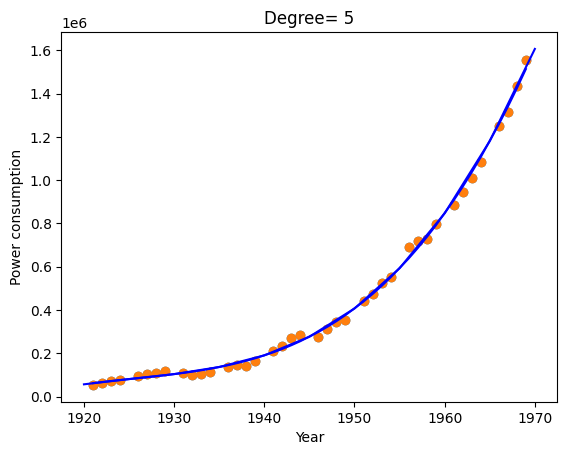

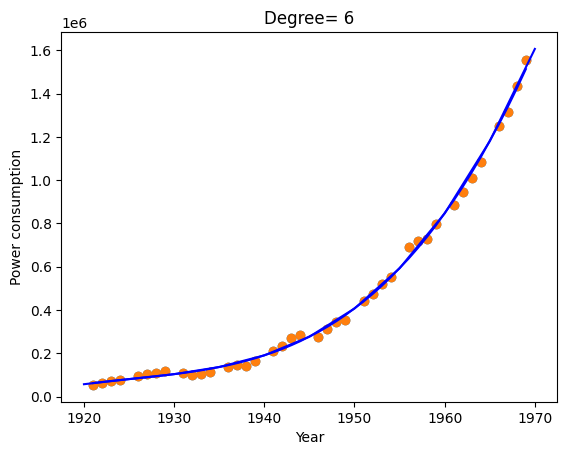

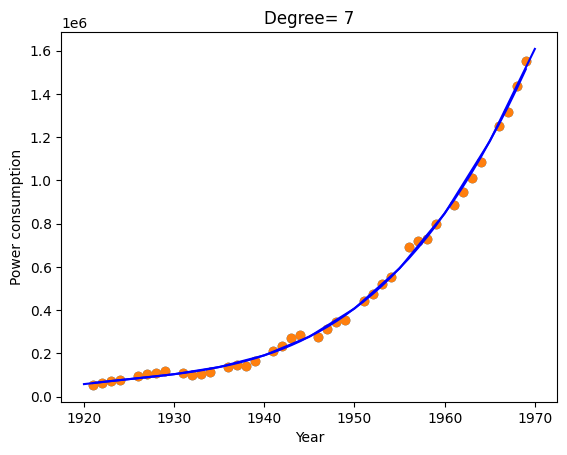

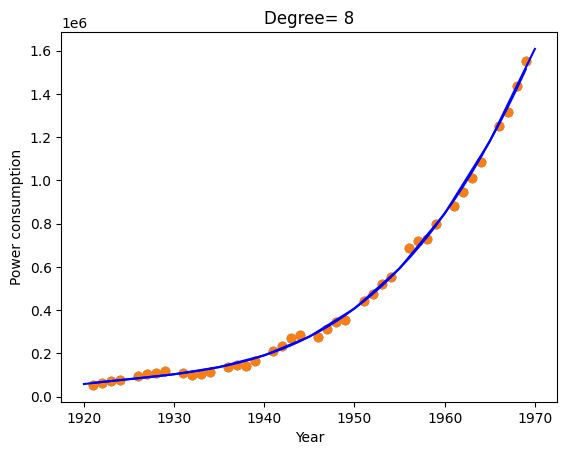

In [70]:
# Doing a polynomial regression: Comparing linear, quadratic and cubic fits
# Pipeline helps you associate two models or objects to be built sequentially with each other,
# in this case, the objects are PolynomialFeatures() and LinearRegression()

r2_train = []
r2_test = []
degrees = [1, 2, 3,4,5,6,7,8 ]

for degree in degrees:
    pipeline = Pipeline([('poly_features', PolynomialFeatures(degree=degree)),
                     ('model', LinearRegression())])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    r2_test.append(metrics.r2_score(y_test, y_pred))

    # training performance
    y_pred_train = pipeline.predict(X_train)
    r2_train.append(metrics.r2_score(y_train, y_pred_train))

# plot predictions and actual values against year
    fig, ax = plt.subplots()
    ax.set_xlabel("Year")
    ax.set_ylabel("Power consumption")
    ax.set_title("Degree= " + str(degree))

    # train data in blue
    ax.scatter(X_train, y_train)
    ax.plot(X_train, y_pred_train, color="blue")

    # test data
    ax.scatter(X_train, y_train)
    ax.plot(X_test, y_pred, color="blue")

    plt.show()

In [71]:
# respective test r-squared scores of predictions
for i in degrees:
    print(f'For degree {i}, train R2 is {r2_train[i-1]} and test R2 is {r2_test[i-1]}')

For degree 1, train R2 is 0.8423747402176137 and test R2 is 0.816517046382681
For degree 2, train R2 is 0.9908896744553399 and test R2 is 0.9876080502675171
For degree 3, train R2 is 0.9979789881922152 and test R2 is 0.9984897454348863
For degree 4, train R2 is 0.9979839891373868 and test R2 is 0.9985021892603536
For degree 5, train R2 is 0.9979886835882551 and test R2 is 0.9985137010295893
For degree 6, train R2 is 0.997993086242269 and test R2 is 0.998524551153771
For degree 7, train R2 is 0.9979972111091164 and test R2 is 0.9985347692760541
For degree 8, train R2 is 0.998001071764312 and test R2 is 0.9985443841291972


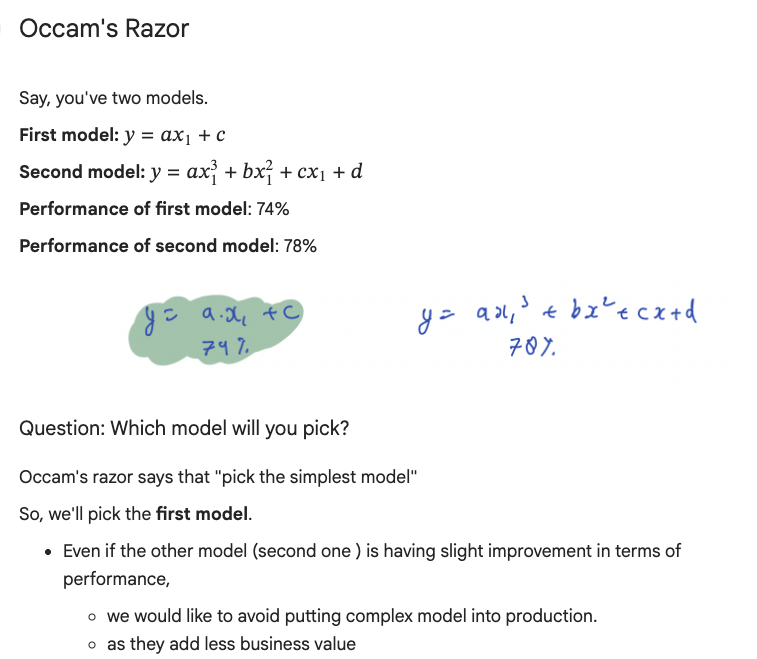

## Overfitting and Underfitting